In [ ]:
############################ TURN LASER ON ############################ 
laser.enable(True)
print(f'Laser enable status: {laser.enable()}')
time.sleep(10)

############################ TURN LASER OFF ############################ 
laser.enable(False)
print(f'Laser enable status: {laser.enable()}')

In [9]:
import time
from time import sleep, monotonic
import datetime
import numpy as np
import matplotlib.pyplot as plt
import sys
import pyvisa
import qcodes as qc
from qcodes.dataset import Measurement
from qcodes.dataset import do0d
from qcodes.dataset.experiment_container import new_experiment, load_experiment_by_name
from qcodes.dataset.plotting import plot_by_id
from qcodes.dataset.data_set import load_by_id, load_by_counter
from qcodes import initialise_or_create_database_at, new_data_set, new_experiment
from qcodes.station import Station
initialise_or_create_database_at("./2026-05-11_SNSPD12.db")
import snspd
params = snspd.snspd('snspd12.yaml')

# Set up experiment
exp_name = 'SNSPD12_29_05_2026'
sample_name = '00'

try:
    exp = qc.load_experiment_by_name(exp_name, sample=sample_name)
    print('Experiment loaded. Last ID no:', exp.last_counter)
except ValueError:
    exp = new_experiment(exp_name, sample_name)
    print('Started new experiment')

Experiment loaded. Last ID no: 330


In [23]:
import importlib
importlib.reload(snspd)
params = snspd.snspd('snspd12.yaml')

In [4]:
station = Station(config_file="friesland.yaml")
dmm = station.load_instrument("dmm", revive_instance=True)
yoko = station.load_instrument("yoko", revive_instance=True)
# laser = station.load_instrument("laser", revive_instance=True)
MS = station.load_instrument("osc", revive_instance=True)
# pm100d = station.load_instrument("pm100d", revive_instance=True) 
# # # pms120 = station.load_instrument("pms120", revive_instance=True)
# # tc = station.load_instrument("fridge", revive_instance=True)
# p_att = station.load_instrument("dmm_keithley", revive_instance=True) # excluding from snapshot because none of the parameters work anyway

In [3]:
MS.horizontal_mode('MANual')

In [5]:
device = params.device_line_2

In [8]:
params.initialize_station()

With single trigger mode incorporated run trace extraction routine for currents. 

In [10]:
params.ramp_yoko_current(yoko=yoko, target=0, step = 0.5e-6)
yoko.current(0)

Ramping to 0


In [11]:
yoko.current()

0.0

In [24]:
params.list_instruments()

('TCPIP0::K-33522B-02071::inst0::INSTR', 'ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL8::INSTR', 'ASRL9::INSTR', 'ASRL10::INSTR', 'ASRL11::INSTR', 'ASRL12::INSTR', 'TCPIP0::10.196.50.27::inst0::INSTR', 'USB0::0x05E6::0x2230::9010428::0::INSTR', 'USB0::0x1313::0x8072::1906768::0::INSTR', 'USB0::0x1313::0x8072::1913782::0::INSTR', 'USB0::0x1313::0x8078::P0033329::0::INSTR', 'TCPIP0::10.196.52.73::inst0::INSTR', 'TCPIP0::10.196.52.75::inst0::INSTR', 'TCPIP0::10.196.52.96::inst0::INSTR')


In [40]:
import pyvisa
rm = pyvisa.ResourceManager()
rm.list_resources()

('TCPIP0::K-33522B-02071::inst0::INSTR',
 'ASRL1::INSTR',
 'ASRL2::INSTR',
 'ASRL5::INSTR',
 'ASRL6::INSTR',
 'ASRL7::INSTR',
 'ASRL8::INSTR',
 'ASRL9::INSTR',
 'ASRL10::INSTR',
 'ASRL11::INSTR',
 'ASRL12::INSTR',
 'TCPIP0::10.196.50.27::inst0::INSTR',
 'USB0::0x05E6::0x2230::9010428::0::INSTR',
 'USB0::0x1313::0x8072::1906768::0::INSTR',
 'USB0::0x1313::0x8072::1913782::0::INSTR',
 'USB0::0x1313::0x8078::P0033329::0::INSTR',
 'TCPIP0::10.196.52.96::inst0::INSTR')

In [41]:
awg = rm.open_resource('TCPIP0::10.196.52.41::inst0::INSTR')

In [42]:
awg

<'TCPIPInstrument'('TCPIP0::10.196.52.41::inst0::INSTR')>

In [43]:
print(awg.query('*IDN?'))

Agilent Technologies,33522B,MY59002071,5.02-3.15-2.00-58-00



In [ ]:
FUNCtion SIN
FREQuency +1.0E+05
VOLTage:HIGH +2.0
VOLTage:LOW +0.0
OUTPut ON
PHASe +90.0

In [70]:
awg.write('FUNCtion SIN')

14

In [67]:
awg.query('FUNCtion SIN')
awg.write('FREQuency +2.0E+05')
awg.write('[SOURce1:]VOLTage:UNIT {VPP}')
# [SOURce[1|2]:]VOLTage:UNIT?')
VOLTage:HIGH +2.0
VOLTage:LOW +0.0
awg.query('VOLTage:HIGH +2.0wr')
awg.write('SOURCE1:VOLT:UNIT VPP')
awg.write('PHASE 0')

9

In [63]:
awg.read_termination = '\n'

In [64]:
awg.read_termination

'\n'

In [132]:
def generate_dataframe(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage):
    data_dict = {}
    for ID in IDrange: 
        data = load_by_id(ID).get_parameter_data()
        trace = data['trace']['trace']
        taxis = data['trace']['time_axis']
        current = data['yoko_current']['yoko_current'][0]
        trigger = data['trigger']['trigger'][0]
        peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
        key = f'{current*1e6:.2f}'

        peak_voltage = 0 if len(peaks)<1 else trace[peaks][0]

        # Set vertical scale based on minimum peak voltage or actual peak voltage
        v_scale = min_peak_voltage/2 if peak_voltage < min_peak_voltage else peak_voltage/2 # <- this was added later 

        threshold1 = mult1*peak_voltage

        threshold2 = mult2*peak_voltage

        if threshold1 < min_threshold1: 
            threshold1 = min_threshold1
        
        if threshold2 < min_threshold2: 
            threshold2 = min_threshold2 
        
        try: 
            v_scale_measured = data['v_scale']['v_scale'][0]
        except KeyError: 
            v_scale_measured = None
        try: 
            data_dict[key]
            print(f'duplicate current {key} ID {ID}')
        except: 
            data_dict[key] = {'current': current, 
                            'trigger': trigger,
                            'v_scale_measured': v_scale_measured,
                            'peak_voltage': peak_voltage,
                            'threshold1': threshold1,
                            'threshold2': threshold2, # does it matter if these are not a multiple of the minimum v_scale_measured?
                            'v_scale': v_scale,
                            'ID': int(ID),
                             }
    return pd.DataFrame(data=data_dict)

In [63]:
def sine_calibration(data, device, osc, awg, cps, n_captures=10, interval=1):
    
    '''
    interval is specified in seconds. FOr MSO5 must be minimum 1s
    '''
    if interval <1: 
        raise Exception('interval must be greater than or equal to 1s')
    
    print('Set standard oscilloscope parameters for counts')
    params.MSO5_set_standard_counts(params.device_line_2, osc)
    time.sleep(2)
    
    # Update experiment snapshot 
    params.update_station(station)
    
    meas = Measurement()
    meas.register_custom_parameter("current", label="A")
    meas.register_custom_parameter("threshold1", label="V")
    meas.register_custom_parameter("threshold2", label="V")
    meas.register_custom_parameter("total_counts1", label="counts")
    meas.register_custom_parameter("total_counts2", label="counts")
    meas.register_custom_parameter("counts1")
    meas.register_custom_parameter("counts2")
    meas.register_custom_parameter("trace_time", label="s")
    meas.register_custom_parameter("meas_time", label="s")
    meas.register_custom_parameter("interval", label="s")
    meas.register_custom_parameter("CR1", label="cps", setpoints=('current',))
    meas.register_custom_parameter("CR2", label="cps", setpoints=('current',))
    meas.register_custom_parameter("n_captures")
    meas.register_custom_parameter('v_scale', label='V')
    meas.register_custom_parameter('frequency', label='Hz')
    meas.register_custom_parameter('amplitude', label='Vpp')
    
    
    with meas.run() as datasaver:
        print(datasaver.run_id)
        
        # save device name 
        datasaver.dataset.add_metadata("device", device['name'])
        
        # Extract the amount of time in one trace 
        h_time = osc.horizontal_scale()*osc.horizontal_divisions()
        
        time.sleep(2)
    
        for key in data.keys(): 
            current = data[key]['current']
            threshold1 = data[key]['threshold1']
            threshold2 = data[key]['threshold2']
            v_scale = data[key]['v_scale']
            peak_voltage = data[key]['peak_voltage']
            
            # Set amplitude based on peak voltage 
            Vpp = peak_voltage*2
    
            # Set AWG parameters 
            awg.write(f'FUNCtion SIN')
            awg.write(f'FREQuency {cps}')
            awg.write('SOURCE1:VOLT:UNIT VPP')
            awg.write('SOURCE1:VOLT:OFFSET 0')
            awg.write(f'VOLT {Vpp}')
            awg.write('PHASE 0')

            
            # Set thresholds and vertical scale 
            osc.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
            osc.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')
            osc.channels[0].vertical_scale(v_scale)    
    
            time.sleep(5)
    
            if osc.channels[0].clipping(): 
                raise Exception('Error: Clipping') 
    
            time.sleep(5)
    
            # Run count 
            osc.write("SEARCH:SEARCH1:STATE 0")
            osc.write("SEARCH:SEARCH1:STATE 1")
            osc.write("SEARCH:SEARCH2:STATE 0")
            osc.write("SEARCH:SEARCH2:STATE 1")
    
            start = time.perf_counter()
            print(f'This acquisition will take {n_captures*interval}s')
            print(datetime.datetime.now().hour,  datetime.datetime.now().minute)
    
            counts1= []
            counts2= []
    
            
            for i in range(n_captures):
                time.sleep(interval)
    
                # Extract counts 
                count1 = int(osc.ask("SEARCH:SEARCH1:TOTal?"))
                count2 = int(osc.ask("SEARCH:SEARCH2:TOTal?"))
    
                counts1.append(count1)
                counts2.append(count2)
    
                
            # calculate total counts 
            total_counts1 = sum(counts1)
            total_counts2 = sum(counts2)
            
            # total time in measurement 
            meas_time = n_captures*h_time
            
            # dark count rate calculation
            CR1 = total_counts1/meas_time
            CR2 = total_counts2/meas_time
            
            # Save data 
            datasaver.add_result(('current', current),
                                ("threshold1",  float(osc.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?'))), 
                                ("threshold2",  float(osc.ask(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold?'))), 
                                ("total_counts1", total_counts1), 
                                ("total_counts2", total_counts2), 
                                ("counts1", counts1), 
                                ("counts2", counts2), 
                                ("meas_time", meas_time), 
                                ("interval", interval), 
                                ("n_captures", n_captures),
                                ("CR1", CR1), 
                                ("CR2", CR2),
                                ("v_scale", float(osc.channels[0].vertical_scale())),
                                ("frequency", float(awg.query('FREQ?'))),
                                 ("amplitude", float(awg.query('VOLT?'))))

In [108]:
range1 = np.arange(121, 173)
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

calibration_data = generate_dataframe(np.concatenate([range3, range2, range1]), mult1=0.8, mult2=0.3, min_threshold2=2*0.006, min_threshold1=0.8*0.024)

duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141


In [112]:
calibration_data

,0.00,-0.25,-0.50,-0.75,-1.00,-1.25,-1.50,-1.75,-2.00,-2.25,...,-10.50,-10.75,-11.00,-11.25,-11.50,-11.75,-12.00,-12.25,-12.50,-12.75
current,0.0000,-2.500000e-07,-5.000000e-07,-7.500000e-07,-0.000001,-0.000001,-0.000002,-0.000002,-0.000002,-0.000002,...,-0.00001,-0.000011,-0.000011,-0.000011,-0.000012,-0.000012,-0.000012,-0.000012,-0.000013,-0.000013
trigger,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.10200,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000
v_scale_measured,0.1500,1.500000e-01,1.500000e-01,1.500000e-01,0.150000,0.150000,0.150000,0.150000,0.150000,0.150000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_voltage,0.0000,0.000000e+00,1.200000e-02,0.000000e+00,0.000000,0.000000,0.000000,0.024000,0.030000,0.036000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
threshold1,0.0192,1.920000e-02,1.920000e-02,1.920000e-02,0.019200,0.019200,0.019200,0.019200,0.024000,0.028800,...,0.01920,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200
threshold2,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.01200,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000
v_scale,0.0000,0.000000e+00,6.000000e-03,0.000000e+00,0.000000,0.000000,0.000000,0.012000,0.015000,0.018000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ID,280.0000,2.810000e+02,2.820000e+02,2.830000e+02,284.000000,285.000000,286.000000,287.000000,288.000000,289.000000,...,163.00000,164.000000,165.000000,166.000000,167.000000,168.000000,169.000000,170.000000,171.000000,172.000000


In [128]:
v_scale_meas = calibration_data.iloc[2]
peak_voltage = calibration_data.iloc[3]
threshold1 = calibration_data.iloc[4]
threshold2 = calibration_data.iloc[5]
v_scale = calibration_data.iloc[6]

In [123]:
np.array(v_scale_meas)

array([0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15,
       0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan])

In [124]:
0.102/0.006

17.0

In [119]:
np.array(peak_voltage)

array([0.   , 0.   , 0.012, 0.   , 0.   , 0.   , 0.   , 0.024, 0.03 ,
       0.036, 0.042, 0.048, 0.054, 0.06 , 0.072, 0.078, 0.078, 0.084,
       0.096, 0.102, 0.102, 0.114, 0.12 , 0.126, 0.126, 0.138, 0.144,
       0.15 , 0.156, 0.162, 0.168, 0.18 , 0.18 , 0.192, 0.198, 0.204,
       0.216, 0.216, 0.222, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])

In [127]:
np.array(v_scale)

array([0.   , 0.   , 0.006, 0.   , 0.   , 0.   , 0.   , 0.012, 0.015,
       0.018, 0.021, 0.024, 0.027, 0.03 , 0.036, 0.039, 0.039, 0.042,
       0.048, 0.051, 0.051, 0.057, 0.06 , 0.063, 0.063, 0.069, 0.072,
       0.075, 0.078, 0.081, 0.084, 0.09 , 0.09 , 0.096, 0.099, 0.102,
       0.108, 0.108, 0.111, 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ])

In [129]:
np.array(threshold1)

array([0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192,
       0.024 , 0.0288, 0.0336, 0.0384, 0.0432, 0.048 , 0.0576, 0.0624,
       0.0624, 0.0672, 0.0768, 0.0816, 0.0816, 0.0912, 0.096 , 0.1008,
       0.1008, 0.1104, 0.1152, 0.12  , 0.1248, 0.1296, 0.1344, 0.144 ,
       0.144 , 0.1536, 0.1584, 0.1632, 0.1728, 0.1728, 0.1776, 0.0192,
       0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192, 0.0192,
       0.0192, 0.0192, 0.0192, 0.0192])

In [130]:
np.array(threshold2)

array([0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 ,
       0.012 , 0.012 , 0.0126, 0.0144, 0.0162, 0.018 , 0.0216, 0.0234,
       0.0234, 0.0252, 0.0288, 0.0306, 0.0306, 0.0342, 0.036 , 0.0378,
       0.0378, 0.0414, 0.0432, 0.045 , 0.0468, 0.0486, 0.0504, 0.054 ,
       0.054 , 0.0576, 0.0594, 0.0612, 0.0648, 0.0648, 0.0666, 0.012 ,
       0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 ,
       0.012 , 0.012 , 0.012 , 0.012 ])

In [67]:
# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
device = params.device_line_2
# data = calibration_data.iloc[:, 25:27]

sine_calibration(calibration_data, device, osc, awg, cps, n_captures=10, interval=1)

Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 309. 
309
This acquisition will take 10s
16 1
This acquisition will take 10s
16 1
This acquisition will take 10s
16 1
This acquisition will take 10s
16 2
This acquisition will take 10s
16 2
This acquisition will take 10s
16 2
This acquisition will take 10s
16 3
This acquisition will take 10s
16 3
This acquisition will take 10s
16 3
This acquisition will take 10s
16 4
This acquisition will take 10s
16 4
This acquisition will take 10s
16 4
This acquisition will take 10s
16 5
This acquisition will take 10s
16 5
This acquisition will take 10s
16 5
This acquisition will take 10s
16 6
This acquisition will take 10s
16 6
This acquisition will take 10s
16 6
This acquisition will take 10s
16 7
This acquisition will take 10s
16 7
This acquisition will take 10s
16 7
This acquisition will take 10s
16 8
This acquisition will take 10s
16 8
This acquisition will take 10s
16 8
This acquisition will take 1

([<Axes: title={'center': 'Run #309, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='A', ylabel='cps'>,
  <Axes: title={'center': 'Run #309, Experiment SNSPD12_29_05_2026 (00)'}, xlabel='A', ylabel='cps'>],
 [None, None])

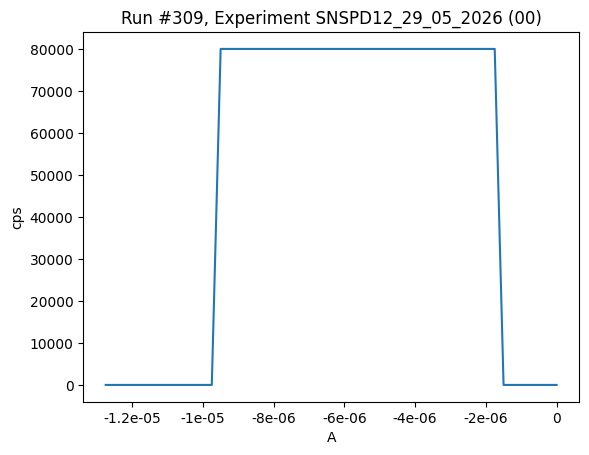

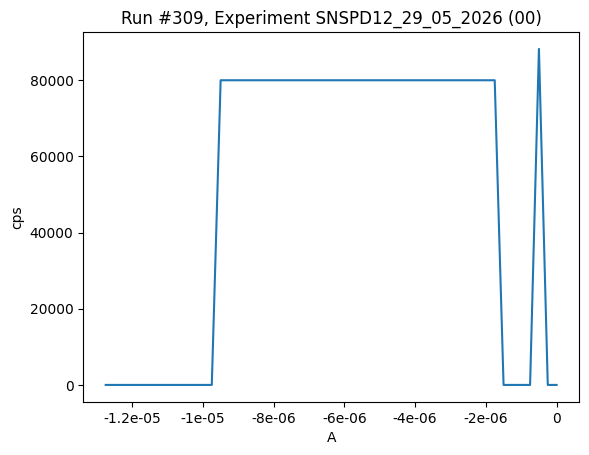

In [68]:
plot_by_id(309)

In [69]:
# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
device = params.device_line_2
# data = calibration_data.iloc[:, 25:27]

for cps in [100e3, 80e3, 50e3, 10e3, 1e3, 500]:
    # Run calibration routine for each frequency level 
    sine_calibration(calibration_data, device, osc, awg, cps, n_captures=10, interval=1)

Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 310. 
310
This acquisition will take 10s
16 29
This acquisition will take 10s
16 30
This acquisition will take 10s
16 30
This acquisition will take 10s
16 30
This acquisition will take 10s
16 31
This acquisition will take 10s
16 31
This acquisition will take 10s
16 31
This acquisition will take 10s
16 32
This acquisition will take 10s
16 32
This acquisition will take 10s
16 32
This acquisition will take 10s
16 33
This acquisition will take 10s
16 33
This acquisition will take 10s
16 33
This acquisition will take 10s
16 34
This acquisition will take 10s
16 34
This acquisition will take 10s
16 34
This acquisition will take 10s
16 35
This acquisition will take 10s
16 35
This acquisition will take 10s
16 35
This acquisition will take 10s
16 36
This acquisition will take 10s
16 36
This acquisition will take 10s
16 36
This acquisition will take 10s
16 37
This acquisition will take 10s
16 37
This

This seems to work. Error when the peak height is zero or in that error region. Could just run for the ones where counts were seen. 
TODO: need to update the counting code to take in the thresholds and scales in a less annoying way! 

In [75]:
data = load_by_id(315).get_parameter_data()

In [76]:
data['CR1']['current']

array([ 0.000e+00, -2.500e-07, -5.000e-07, -7.500e-07, -1.000e-06,
       -1.250e-06, -1.500e-06, -1.750e-06, -2.000e-06, -2.250e-06,
       -2.500e-06, -2.750e-06, -3.000e-06, -3.250e-06, -3.500e-06,
       -3.750e-06, -4.000e-06, -4.250e-06, -4.500e-06, -4.750e-06,
       -5.000e-06, -5.250e-06, -5.500e-06, -5.750e-06, -6.000e-06,
       -6.250e-06, -6.500e-06, -6.750e-06, -7.000e-06, -7.250e-06,
       -7.500e-06, -7.750e-06, -8.000e-06, -8.250e-06, -8.500e-06,
       -8.750e-06, -9.000e-06, -9.250e-06, -9.500e-06, -9.750e-06,
       -1.000e-05, -1.025e-05, -1.050e-05, -1.075e-05, -1.100e-05,
       -1.125e-05, -1.150e-05, -1.175e-05, -1.200e-05, -1.225e-05,
       -1.250e-05, -1.275e-05])

In [77]:
data['CR1']['CR1']

array([  0.,   0.,   0.,   0.,   0.,   0.,   0., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500., 500., 500., 500., 500., 500.,
       500., 500., 500., 500., 500., 500.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.])

The trace looked very noisy on the screen and I am realy not sure how it could have counted the 500Hz ones. 

Get the pulse waveform

In [74]:
# Should fix the bug and get the next one up 

In [ ]:
FUNC PULS
FUNC:PULS:TRAN:LEAD 4E-8
FUNC:PULS:TRAN:TRA 1E-6
FUNC:PULS:WIDT 3E-6
FREQ 2E5
VOLT 3
OUTP ON

In [88]:
# minimum rise, fall and width parameters 
rise = 8.4e-9
fall = 8.4e-9
width = 16e-9
cps = 80e3
vpeak = 400e-3
# Set AWG parameters 
awg.write('SOURCE1:VOLT:UNIT Vpp')
awg.write(f'SOURCE1:VOLT:OFFSET {vpeak/2}')
awg.write(f'FUNC PULS')
awg.write(f'FUNC:PULS:TRAN:LEAD {rise}')
awg.write(f'FUNC:PULS:TRAN:TRA {fall}')
awg.write(f'FUNC:PULS:WIDT {width}')
awg.write(f'FREQ {cps}')
awg.write(f'VOLT {vpeak}')
awg.write('OUTP ON')

9

In [156]:
def pulse_test_calibration(data, device, osc, awg, cps, n_captures=10, interval=1):
    
    '''
    interval is specified in seconds. FOr MSO5 must be minimum 1s
    '''
    if interval <1: 
        raise Exception('interval must be greater than or equal to 1s')
    
    print('Set standard oscilloscope parameters for counts')
    params.MSO5_set_standard_counts(params.device_line_2, osc)
    time.sleep(2)
    
    # Update experiment snapshot 
    params.update_station(station)
    
    meas = Measurement()
    meas.register_custom_parameter("current", label="A")
    meas.register_custom_parameter("threshold1", label="V")
    meas.register_custom_parameter("threshold2", label="V")
    meas.register_custom_parameter("total_counts1", label="counts")
    meas.register_custom_parameter("total_counts2", label="counts")
    meas.register_custom_parameter("counts1")
    meas.register_custom_parameter("counts2")
    meas.register_custom_parameter("trace_time", label="s")
    meas.register_custom_parameter("meas_time", label="s")
    meas.register_custom_parameter("interval", label="s")
    meas.register_custom_parameter("CR1", label="cps", setpoints=('current',))
    meas.register_custom_parameter("CR2", label="cps", setpoints=('current',))
    meas.register_custom_parameter("n_captures")
    meas.register_custom_parameter('v_scale', label='V')
    meas.register_custom_parameter('frequency', label='Hz')
    meas.register_custom_parameter('amplitude', label='Vpp')
    
    
    with meas.run() as datasaver:
        print(datasaver.run_id)
        
        # save device name 
        datasaver.dataset.add_metadata("device", device['name'])
        
        # Extract the amount of time in one trace 
        h_time = osc.horizontal_scale()*osc.horizontal_divisions()
        
        time.sleep(2)
    
        for key in data.keys(): 
            current = data[key]['current']
            threshold1 = data[key]['threshold1']
            threshold2 = data[key]['threshold2']
            v_scale = data[key]['v_scale']
            test_peak_voltage = data[key]['test_peak_voltage']
            

            # minimum rise, fall and width parameters 
            rise = 8.4e-9
            fall = 8.4e-9
            width = 16e-9

            # Set AWG parameters 
            awg.write('SOURCE1:VOLT:UNIT Vpp')
            awg.write(f'SOURCE1:VOLT:OFFSET {test_peak_voltage/2}')
            awg.write(f'FUNC PULS')
            awg.write(f'FUNC:PULS:TRAN:LEAD {rise}')
            awg.write(f'FUNC:PULS:TRAN:TRA {fall}')
            awg.write(f'FUNC:PULS:WIDT {width}')
            awg.write(f'FREQ {cps}')
            awg.write(f'VOLT {test_peak_voltage}')
            awg.write('OUTP ON')

            
            # Set thresholds and vertical scale 
            osc.write(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold {threshold1}')
            osc.write(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold {threshold2}')
            osc.channels[0].vertical_scale(v_scale)    
    
            time.sleep(5)
    
            if osc.channels[0].clipping(): 
                raise Exception('Error: Clipping') 
    
            time.sleep(5)
    
            osc.write("SEARCH:SEARCH1:STATE 0")
            osc.write("SEARCH:SEARCH1:STATE 1")
            osc.write("SEARCH:SEARCH2:STATE 0")
            osc.write("SEARCH:SEARCH2:STATE 1")
    
            start = time.perf_counter()
            print(f'This acquisition will take {n_captures*interval}s')
            print(datetime.datetime.now().hour,  datetime.datetime.now().minute)
    
            counts1= []
            counts2= []
    
            
            for i in range(n_captures):
                time.sleep(interval)
    
                # Extract counts 
                count1 = int(osc.ask("SEARCH:SEARCH1:TOTal?"))
                count2 = int(osc.ask("SEARCH:SEARCH2:TOTal?"))
    
                counts1.append(count1)
                counts2.append(count2)
    
                
            # calculate total counts 
            total_counts1 = sum(counts1)
            total_counts2 = sum(counts2)
            
            # total time in measurement 
            meas_time = n_captures*h_time
            
            # dark count rate calculation
            CR1 = total_counts1/meas_time
            CR2 = total_counts2/meas_time
            
            # Save data 
            datasaver.add_result(('current', current),
                                ("threshold1",  float(osc.ask(f'SEARCH:SEARCH1:TRIGger:A:EDGE:THReshold?'))), 
                                ("threshold2",  float(osc.ask(f'SEARCH:SEARCH2:TRIGger:A:EDGE:THReshold?'))), 
                                ("total_counts1", total_counts1), 
                                ("total_counts2", total_counts2), 
                                ("counts1", counts1), 
                                ("counts2", counts2), 
                                ("meas_time", meas_time), 
                                ("interval", interval), 
                                ("n_captures", n_captures),
                                ("CR1", CR1), 
                                ("CR2", CR2),
                                ("v_scale", float(osc.channels[0].vertical_scale())),
                                ("frequency", float(awg.query('FREQ?'))),
                                 ("amplitude", float(awg.query('VOLT?'))))

In [151]:
# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
device = params.device_line_2
# data = calibration_data.iloc[:, 25:27]

pulse_calibration(calibration_data, device, osc, awg, cps, n_captures=10, interval=1)

Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 319. 
319
This acquisition will take 10s
16 43


2026-06-15 16:44:00,919 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: d05f28a4-0000-0000-0000-019eca059636;
Traceback:
Traceback (most recent call last):
  File "C:\Users\QNL\AppData\Local\Temp\ipykernel_25396\3590759266.py", line 98, in pulse_calibration
    time.sleep(interval)
    ~~~~~~~~~~^^^^^^^^^^
KeyboardInterrupt



KeyboardInterrupt: 

In [145]:
data = load_by_id(317).get_parameter_data()

In [97]:
data['CR1']['CR1']

array([    0.,     0.,     0.,     0.,     0.,     0.,     0., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.])

In [146]:
data['CR2']['CR2']

array([    0.,     0.,  9975.,     0.,     0.,     0.,     0., 80000.,
       80000., 79999., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 79999., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000.,     0.,
           0.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
           0.,     0.,     0.,     0.])

It might be worth doing a sweep where I reduce the vertical scale to check that the count goes awry as I think it will...

In [98]:
data.keys()

dict_keys(['CR1', 'CR2', 'amplitude', 'counts1', 'counts2', 'frequency', 'interval', 'meas_time', 'n_captures', 'threshold1', 'threshold2', 'total_counts1', 'total_counts2', 'trace_time', 'v_scale'])

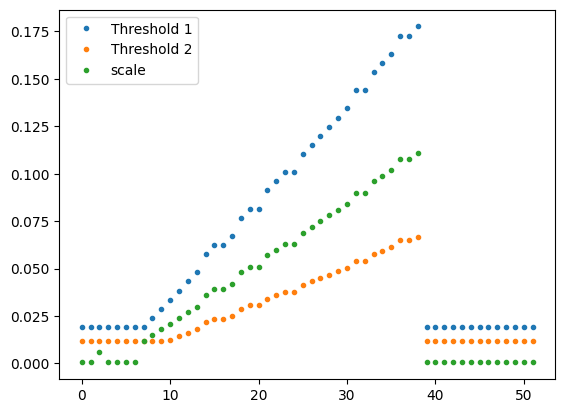

In [107]:
plt.plot(data['threshold1']['threshold1'], '.', label='Threshold 1')
plt.plot(data['threshold2']['threshold2'], '.', label='Threshold 2')
plt.plot(data['v_scale']['v_scale'], '.', label='scale')
plt.legend()

data['v_scale']['v_scale']

# Re-doing with vertical scale set correctly

In [163]:
range1 = np.arange(121, 173)
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

IDrange = np.concatenate([range3, range2, range1])

mult1 = 0.8 
mult2 = 0.3
min_peak_voltage = 0.024 # smallest voltage measured in calibration 
min_threshold2=0.5*min_peak_voltage # set just below mult2*min_peak_voltage
min_threshold1=mult1*min_peak_voltage #

calibration_data = params.generate_dataframe(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage)

duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141


In [164]:
calibration_data

,0.00,-0.25,-0.50,-0.75,-1.00,-1.25,-1.50,-1.75,-2.00,-2.25,...,-10.50,-10.75,-11.00,-11.25,-11.50,-11.75,-12.00,-12.25,-12.50,-12.75
current,0.0000,-2.500000e-07,-5.000000e-07,-7.500000e-07,-0.000001,-0.000001,-0.000002,-0.000002,-0.000002,-0.000002,...,-0.00001,-0.000011,-0.000011,-0.000011,-0.000012,-0.000012,-0.000012,-0.000012,-0.000013,-0.000013
trigger,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.10200,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000
v_scale_measured,0.1500,1.500000e-01,1.500000e-01,1.500000e-01,0.150000,0.150000,0.150000,0.150000,0.150000,0.150000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_voltage,0.0000,0.000000e+00,1.200000e-02,0.000000e+00,0.000000,0.000000,0.000000,0.024000,0.030000,0.036000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
test_peak_voltage,0.0240,2.400000e-02,2.400000e-02,2.400000e-02,0.024000,0.024000,0.024000,0.024000,0.030000,0.036000,...,0.02400,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000
threshold1,0.0192,1.920000e-02,1.920000e-02,1.920000e-02,0.019200,0.019200,0.019200,0.019200,0.024000,0.028800,...,0.01920,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200
threshold2,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.01200,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000
v_scale,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.015000,0.018000,...,0.01200,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000
ID,280.0000,2.810000e+02,2.820000e+02,2.830000e+02,284.000000,285.000000,286.000000,287.000000,288.000000,289.000000,...,163.00000,164.000000,165.000000,166.000000,167.000000,168.000000,169.000000,170.000000,171.000000,172.000000


In [166]:
params.args(params.pulse_test_calibration)

(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage, device, osc, awg, cps, n_captures=10, interval=1, station=None)


In [170]:
range1 = np.arange(121, 173)
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

IDrange = np.concatenate([range3, range2, range1])

mult1 = 0.8 
mult2 = 0.3
min_peak_voltage = 0.024 # smallest voltage measured in calibration 
min_threshold2=0.5*min_peak_voltage # set just below mult2*min_peak_voltage
min_threshold1=mult1*min_peak_voltage #

device=params.device_line_2

# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
device = params.device_line_2
# data = calibration_data.iloc[:, 25:27]
# IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage
params.pulse_test_calibration(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage, device, osc, awg, cps, n_captures=10, interval=1)

duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 323. 
323
This acquisition will take 10s
16 59
This acquisition will take 10s
16 59
This acquisition will take 10s
16 59
This acquisition will take 10s
17 0
This acquisition will take 10s
17 0
This acquisition will take 1

In [173]:
data=load_by_id(323).get_parameter_data()

In [174]:
data['CR1']['CR1']

array([80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000.])

In [177]:
data['CR2']['CR2'][9]

np.float64(79999.0)

In [180]:
data['amplitude']['amplitude'][9]

np.float64(0.036)

In [197]:
# minimum rise, fall and width parameters 
rise = 8.4e-9
fall = 8.4e-9
width = 16e-9
cps = 80e3
test_peak_voltage = 0.036

# Set AWG parameters 
awg.write('SOURCE1:VOLT:UNIT Vpp')
awg.write(f'SOURCE1:VOLT:OFFSET {test_peak_voltage/2}')
awg.write(f'FUNC PULS')
awg.write(f'FUNC:PULS:TRAN:LEAD {rise}')
awg.write(f'FUNC:PULS:TRAN:TRA {fall}')
awg.write(f'FUNC:PULS:WIDT {width}')
awg.write(f'FREQ {cps}')
awg.write(f'VOLT {test_peak_voltage}')
awg.write('OUTP ON')

9

In [195]:
np.array(calibration_data.loc['test_peak_voltage'])[9]

np.float64(0.036)

In [189]:
np.array(calibration_data.loc['threshold2'])[9]

np.float64(0.012)

In [196]:
np.array(calibration_data.loc['threshold1'])[9]

np.float64(0.0288)

In [193]:
data['v_scale']['v_scale'][9]

np.float64(0.018)

Manually looked at settings for Amplitude 0.036. Count briefly oscillate dbetween 7 and 8 Hz. When cps was set to 80000, it was clear that the trigger location affects whether search 2 and search 1 read 8000 or 7999. I think this somewhat makes sense because it affects what is on the screen. Both search functions read correctly if the trigger is set one scale division below the trace. I will write this in. 


Maybe set thresholds should be in the set for counts function and along with the setting the location of the trigger. 
Whatever the case the idea is that the counting settings should be identical to the calibration settings. 


Also does the search edge function show the average over a second or something and does that change things? 

In [208]:
range1 = np.arange(121, 173)
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

IDrange = np.concatenate([range3, range2, range1])

mult1 = 0.8 
mult2 = 0.3
min_peak_voltage = 0.024 # smallest voltage measured in calibration 
min_threshold2=0.5*min_peak_voltage # set just below mult2*min_peak_voltage
min_threshold1=mult1*min_peak_voltage #

device=params.device_line_2

# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
# data = calibration_data.iloc[:, 25:27]
# IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage
params.pulse_test_calibration(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage, device, osc, awg, cps, n_captures=10, interval=1, trigger=0)

duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 327. 
327
This acquisition will take 10s
17 43
This acquisition will take 10s
17 43
This acquisition will take 10s
17 43
This acquisition will take 10s
17 44
This acquisition will take 10s
17 44
This acquisition will take

In [209]:
data=load_by_id(327).get_parameter_data()

In [211]:
data['CR1']['CR1']

array([80000., 80000., 80000., 80000., 80000., 80000., 80000., 79999.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 79999., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 79999., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 79999., 80000.,
       80000., 80000., 80000., 79999., 80000., 80000., 80000., 79999.,
       80000., 80000., 79999., 80000.])

In [210]:
data['CR2']['CR2']

array([80000., 80000., 80000., 80000., 80000., 80000., 80000., 79999.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 79999., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 79999., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 79999., 80000.,
       80000., 80000., 80000., 79999., 80000., 80000., 80000., 79999.,
       80000., 80000., 79999., 80000.])

Somehow that made it worse?? I really don't understand what is happening with the oscilloscope. Making trigger settable externally so that I can experiment with this later.

Running again with trigger at zero. 

In [71]:
0.024*0.8

0.019200000000000002

In [215]:
range1 = np.arange(121, 173)
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

IDrange = np.concatenate([range3, range2, range1])

mult1 = 0.8 
mult2 = 0.3
min_peak_voltage = 0.024 # smallest voltage measured in calibration 
min_threshold2=0.5*min_peak_voltage # set just below mult2*min_peak_voltage
min_threshold1=mult1*min_peak_voltage #

device=params.device_line_2

# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
# data = calibration_data.iloc[:, 25:27]
# IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage
params.pulse_test_calibration(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage, device, osc, awg, cps, n_captures=10, interval=1, trigger=0)

duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141
Set standard oscilloscope parameters for counts
update station
Starting experimental run with id: 328. 
328
This acquisition will take 10s
23 18
This acquisition will take 10s
23 19
This acquisition will take 10s
23 19
This acquisition will take 10s
23 19
This acquisition will take 10s
23 20
This acquisition will take

In [218]:
data=load_by_id(328).get_parameter_data()

In [220]:
data['CR1']['CR1']

array([80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000.])

In [219]:
data['CR2']['CR2']

array([80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 79999., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 79999., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000., 80000., 80000., 80000., 80000.,
       80000., 80000., 80000., 80000.])

In [225]:
params.args(params.trace_vs_current)

(device, MS, dmm, yoko, p_att, trigger, v_scale, wait=120, currents=None, station=None)


In [224]:
MS.channels[0].vertical_scale()

0.012

In [14]:
device=params.device_line_2
params.trace_vs_current(device, MS, dmm, yoko, p_att=dmm, trigger=0, v_scale=0.012, wait=120,currents=[1e-6, 2e-6])

Oscilloscope set for trace capture
update station
Ramping to 0
Starting experimental run with id: 333. 
333
Oscilloscope set for trace capture
update station
Acquisition took 2.03 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1
Oscilloscope set for trace capture
update station
Acquisition took 2.03 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


In [15]:
data=load_by_id(333).get_parameter_data()

In [16]:
data['trace']['trace']

array([ 0.  , -0.04, -0.04, ..., -0.04, -0.04,  0.  ], shape=(3750,))

In [18]:
data['dmm_volt']['dmm_volt']

array([-5.18194119e-07, -3.31676684e-07,             nan, ...,
                   nan,             nan,             nan], shape=(3750,))

In [24]:
device=params.device_line_2
params.single_trace_capture(device, MS, dmm, yoko, p_att=dmm, trigger=0, v_scale=0.012, wait=120)

Oscilloscope set for trace capture
update station
Starting experimental run with id: 334. 
334
Oscilloscope set for trace capture
update station
Acquisition took 2.03 seconds
1;8;BINARY;RI;INTEGER;MSB;"Ch1, DC coupling, 256V/div, 300ns/div, 1875 points, Sample mode";1875;Y;LINEAR;"s";1.60E-9;955.000E-12;188;"V";40.0000E-3;0.0E+0;0.0E+0;TIME;ANALOG;0.0E+0;0.0E+0;1


2026-06-16 00:11:42,533 ¦ qcodes.dataset.measurements ¦ WARNING ¦ measurements ¦ __exit__ ¦ 758 ¦ An exception occurred in measurement with guid: ea0b7a76-0000-0000-0000-019ecb9f5733;
Traceback:
Traceback (most recent call last):
  File "D:\SNSPD\SNSPD2\snspd.py", line 608, in single_trace_capture
    ('v_attenuator', float(p_att.ask('VOLT?'))),
                           ~~~~~~~~~^^^^^^^^^
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\instrument.py", line 445, in ask
    raise e
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\instrument.py", line 439, in ask
    answer = self.ask_raw(cmd)
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\qcodes\instrument\visa.py", line 394, in ask_raw
    response = self.visa_handle.query(cmd)
  File "C:\Users\QNL\anaconda3\envs\qcodes\Lib\site-packages\pyvisa\resources\messagebased.py", line 702, in query
    return self.read()
           ~~~~~~~~~^^
  File "C:\Users\QNL\anac

VisaIOError: ('VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.', "asking 'VOLT?' to <Keysight34410A: dmm>")

IndexError: index 0 is out of bounds for axis 0 with size 0

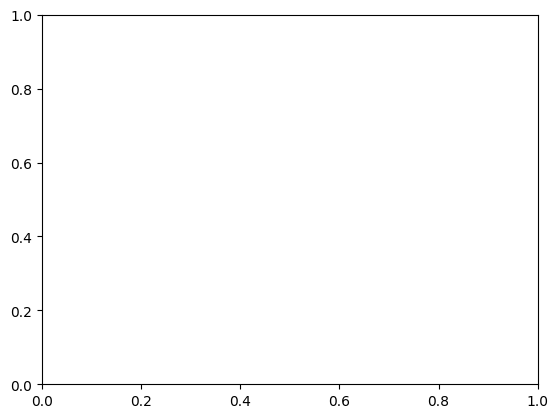

In [25]:
plot_by_id(334)

Generating data set for calibration

In [81]:
data = load_by_id(173).get_parameter_data()
data['yoko_current']['yoko_current']

array([-1.3e-05])

In [30]:
range1 = np.arange(121, 173) # note: this range  thing that 
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

IDrange = np.concatenate([range3, range2, range1])

mult1 = 0.8 
mult2 = 0.3
min_peak_voltage = 0.024 # smallest voltage measured in calibration 
min_threshold2=0.5*min_peak_voltage # set just below mult2*min_peak_voltage
print(f'min_threshold2 is {min_threshold2}')
min_threshold1=mult1*min_peak_voltage #

device=params.device_line_2

# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
# data = calibration_data.iloc[:, 25:27]
# IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage
calibration_data = params.generate_dataframe(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage)

min_threshold2 is 0.012
duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141


In [48]:
calibration_data

,0.00,-0.25,-0.50,-0.75,-1.00,-1.25,-1.50,-1.75,-2.00,-2.25,...,-10.50,-10.75,-11.00,-11.25,-11.50,-11.75,-12.00,-12.25,-12.50,-12.75
current,0.0000,-2.500000e-07,-5.000000e-07,-7.500000e-07,-0.000001,-0.000001,-0.000002,-0.000002,-0.000002,-0.000002,...,-0.00001,-0.000011,-0.000011,-0.000011,-0.000012,-0.000012,-0.000012,-0.000012,-0.000013,-0.000013
trigger,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.10200,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000
v_scale_measured,0.1500,1.500000e-01,1.500000e-01,1.500000e-01,0.150000,0.150000,0.150000,0.150000,0.150000,0.150000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_voltage,0.0000,0.000000e+00,1.200000e-02,0.000000e+00,0.000000,0.000000,0.000000,0.024000,0.030000,0.036000,...,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
test_peak_voltage,0.0240,2.400000e-02,2.400000e-02,2.400000e-02,0.024000,0.024000,0.024000,0.024000,0.030000,0.036000,...,0.02400,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000
threshold1,0.0192,1.920000e-02,1.920000e-02,1.920000e-02,0.019200,0.019200,0.019200,0.019200,0.024000,0.028800,...,0.01920,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200
threshold2,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.01200,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000
v_scale,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.015000,0.018000,...,0.01200,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000
ID,280.0000,2.810000e+02,2.820000e+02,2.830000e+02,284.000000,285.000000,286.000000,287.000000,288.000000,289.000000,...,163.00000,164.000000,165.000000,166.000000,167.000000,168.000000,169.000000,170.000000,171.000000,172.000000


In [35]:
ID = np.array(calibration_data.loc['ID'])[0]
data = load_by_id(ID).get_parameter_data()

In [76]:
np.array(calibration_data.loc['v_scale_measured'])

array([0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15,
       0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15, 0.15,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan,
        nan,  nan,  nan,  nan,  nan,  nan,  nan,  nan])

In [75]:
np.array(calibration_data.loc['trigger'])

array([0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012, 0.012,
       0.012, 0.012, 0.048, 0.048, 0.048, 0.048, 0.048, 0.048, 0.048,
       0.048, 0.048, 0.048, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102,
       0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102,
       0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102,
       0.102, 0.102, 0.102, 0.102, 0.102, 0.102, 0.102])

In [78]:
np.array(calibration_data.loc['current'])

array([ 0.000e+00, -2.500e-07, -5.000e-07, -7.500e-07, -1.000e-06,
       -1.250e-06, -1.500e-06, -1.750e-06, -2.000e-06, -2.250e-06,
       -2.500e-06, -2.750e-06, -3.000e-06, -3.250e-06, -3.500e-06,
       -3.750e-06, -4.000e-06, -4.250e-06, -4.500e-06, -4.750e-06,
       -5.000e-06, -5.250e-06, -5.500e-06, -5.750e-06, -6.000e-06,
       -6.250e-06, -6.500e-06, -6.750e-06, -7.000e-06, -7.250e-06,
       -7.500e-06, -7.750e-06, -8.000e-06, -8.250e-06, -8.500e-06,
       -8.750e-06, -9.000e-06, -9.250e-06, -9.500e-06, -9.750e-06,
       -1.000e-05, -1.025e-05, -1.050e-05, -1.075e-05, -1.100e-05,
       -1.125e-05, -1.150e-05, -1.175e-05, -1.200e-05, -1.225e-05,
       -1.250e-05, -1.275e-05])

In [74]:
from ipywidgets import interact, fixed, IntSlider
from scipy.signal import find_peaks
def plot_count_calibration(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage): 
        data = params.generate_dataframe(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage)
        IDs = np.array(data.loc['ID'])
    
        def plot_traces(idx, data):
            ID = np.array(data.loc['ID'])[idx]
            threshold1 = np.array(data.loc['threshold1'])[idx]
            threshold2 = np.array(data.loc['threshold2'])[idx]
            peak_voltage = np.array(data.loc['peak_voltage'])[idx]
            v_scale = np.array(data.loc['v_scale'])[idx]
            
            data = load_by_id(ID).get_parameter_data()
            trace = data['trace']['trace']
            taxis = data['trace']['time_axis']
            current = data['yoko_current']['yoko_current']
            trigger = data['trigger']['trigger'][0]
            plt.plot(taxis, trace)
            peaks, properties = find_peaks(trace, height=float(trigger), distance=len(trace))
            plt.plot(taxis, np.ones_like(taxis)*float(trigger), label=f'Trigger in sweep {trigger*1e3}mV')
            plt.plot(taxis, np.ones_like(taxis)*threshold1, label=f'Threshold1 {mult1*100}% {threshold1*1e3}mV')
            plt.plot(taxis, np.ones_like(taxis)*threshold2, label=f'Threshold2 {mult2*100}% {threshold2*1e3} mV')
            plt.plot(taxis[peaks],trace[peaks], 'ro', label=f'Peak {trace[peaks]*1e3}mV')
            plt.title(f'ID: {ID} Current: {current[0]*1e6}uA\nVertical Scale: {v_scale}')
            plt.legend()
            plt.ylabel('Voltage (V)')
            plt.xlabel('Time (s)')
                
        interact(plot_traces, idx=IntSlider(min=0, max=len(IDs), step=1, value=0,
                                          continuous_update=False), data=fixed(data));


In [69]:
plot_count_calibration(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage)

duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141


interactive(children=(IntSlider(value=0, continuous_update=False, description='idx', max=52), Output()), _dom_…

In [27]:
params.args(params.generate_dataframe)

(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage)


In [82]:
range1 = np.arange(121, 174) # note: this range  thing that 
range2 = np.arange(261, 272)
range3 = np.arange(280, 291)

IDrange = np.concatenate([range3, range2, range1])

mult1 = 0.8 
mult2 = 0.3
min_peak_voltage = 0.024 # smallest voltage measured in calibration 
min_threshold2=0.5*min_peak_voltage # set just below mult2*min_peak_voltage
print(f'min_threshold2 is {min_threshold2}')
min_threshold1=mult1*min_peak_voltage #

device=params.device_line_2

# Set oscilloscope variable 
n_captures = 10 
interval = 1 
osc = MS 
cps = 80e3 
# data = calibration_data.iloc[:, 25:27]
# IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage
calibration_data = params.generate_dataframe(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage)

min_threshold2 is 0.012
duplicate current -2.50 ID 261
duplicate current 0.00 ID 121
duplicate current -0.25 ID 122
duplicate current -0.50 ID 123
duplicate current -0.75 ID 124
duplicate current -1.00 ID 125
duplicate current -1.25 ID 126
duplicate current -1.50 ID 127
duplicate current -1.75 ID 128
duplicate current -2.00 ID 129
duplicate current -2.25 ID 130
duplicate current -2.50 ID 131
duplicate current -2.75 ID 132
duplicate current -3.00 ID 133
duplicate current -3.25 ID 134
duplicate current -3.50 ID 135
duplicate current -3.75 ID 136
duplicate current -4.00 ID 137
duplicate current -4.25 ID 138
duplicate current -4.50 ID 139
duplicate current -4.75 ID 140
duplicate current -5.00 ID 141


In [83]:
calibration_data

,0.00,-0.25,-0.50,-0.75,-1.00,-1.25,-1.50,-1.75,-2.00,-2.25,...,-10.75,-11.00,-11.25,-11.50,-11.75,-12.00,-12.25,-12.50,-12.75,-13.00
current,0.0000,-2.500000e-07,-5.000000e-07,-7.500000e-07,-0.000001,-0.000001,-0.000002,-0.000002,-0.000002,-0.000002,...,-0.000011,-0.000011,-0.000011,-0.000012,-0.000012,-0.000012,-0.000012,-0.000013,-0.000013,-0.000013
trigger,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000,0.102000
v_scale_measured,0.1500,1.500000e-01,1.500000e-01,1.500000e-01,0.150000,0.150000,0.150000,0.150000,0.150000,0.150000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
peak_voltage,0.0000,0.000000e+00,1.200000e-02,0.000000e+00,0.000000,0.000000,0.000000,0.024000,0.030000,0.036000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
test_peak_voltage,0.0240,2.400000e-02,2.400000e-02,2.400000e-02,0.024000,0.024000,0.024000,0.024000,0.030000,0.036000,...,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000,0.024000
threshold1,0.0192,1.920000e-02,1.920000e-02,1.920000e-02,0.019200,0.019200,0.019200,0.019200,0.024000,0.028800,...,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200,0.019200
threshold2,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,...,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000
v_scale,0.0120,1.200000e-02,1.200000e-02,1.200000e-02,0.012000,0.012000,0.012000,0.012000,0.015000,0.018000,...,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000,0.012000
ID,280.0000,2.810000e+02,2.820000e+02,2.830000e+02,284.000000,285.000000,286.000000,287.000000,288.000000,289.000000,...,164.000000,165.000000,166.000000,167.000000,168.000000,169.000000,170.000000,171.000000,172.000000,173.000000


In [88]:
np.array(calibration_data.loc['threshold2'])

array([0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 ,
       0.012 , 0.012 , 0.0126, 0.0144, 0.0162, 0.018 , 0.0216, 0.0234,
       0.0234, 0.0252, 0.0288, 0.0306, 0.0306, 0.0342, 0.036 , 0.0378,
       0.0378, 0.0414, 0.0432, 0.045 , 0.0468, 0.0486, 0.0504, 0.054 ,
       0.054 , 0.0576, 0.0594, 0.0612, 0.0648, 0.0648, 0.0666, 0.012 ,
       0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 , 0.012 ,
       0.012 , 0.012 , 0.012 , 0.012 , 0.012 ])

In [ ]:
plot_count_calibration(IDrange, mult1, mult2, min_threshold2, min_threshold1, min_peak_voltage)